# STUDD on Electricity dataset

This notebook applies STUDD to the real-world Electricity stream.

For this dataset, we follow the model choice reported for the paper experiment:

- teacher: Naive Bayes
- student: XGB-style model, approximated in CapyMOA with StreamingGradientBoostedTrees
- detector: Page-Hinkley with $\delta = 0.001$
- initial training window: $W = 2000$

No adaptation is performed after drift alarms in this notebook.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.datasets import Electricity
from capymoa.drift.detectors import STUDD, PageHinkley

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
    collect_instances,
)

configure_matplotlib()

## Parameters

The Electricity experiment uses:

- $W = 2000$
- Naive Bayes teacher
- Streaming Gradient Boosted Trees student
- Page-Hinkley detector with $\delta = 0.001$

The true drift locations are unknown, so alarms are interpreted as detected change points rather than matched against ground truth.

In [2]:
W = 2_000
N_TREES = 100
PH_DELTA = 0.001
SEED = 1

TEACHER_TYPE = "rf"
STUDENT_TYPE = "rf"

window = 200
LOCAL_WINDOW = 5000

## Load Electricity stream

The first $W$ instances are used as the initial labeled reference window for training the teacher.

The remaining observations are processed sequentially by STUDD.

In [3]:
reference_stream = Electricity()
schema = reference_stream.get_schema()

reference_instances = collect_instances(reference_stream, W)

monitor_stream = Electricity()

for _ in range(W):
    if monitor_stream.has_more_instances():
        monitor_stream.next_instance()

## Train teacher

The teacher is trained on the initial reference window.
After this phase, the teacher remains fixed during monitoring.

For Electricity, we use Naive Bayes as teacher.

In [4]:
teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

for instance in reference_instances:
    teacher.train(instance)

print(f"Teacher trained on {len(reference_instances)} instances.")
print(f"Teacher type: {TEACHER_TYPE}")

Teacher trained on 2000 instances.
Teacher type: rf


## STUDD detector

STUDD compares teacher predictions with student predictions.

CapyMOA stores the teacher–student agreement signal:

$$
a_t = \mathbb{I}(\hat{y}_T = \hat{y}_S)
$$

For interpretation, we convert it to disagreement / imitation error:

$$
e_t = 1 - a_t
$$

The base detector is Page-Hinkley.

In [5]:
student = make_student(
    schema=schema,
    student_type=STUDENT_TYPE,
    seed=SEED + 1,
    n_trees=N_TREES,
)

studd = STUDD(
    student=student,
    min_n_instances=W,
    detector=PageHinkley(delta=PH_DELTA),
)

print(f"Student type: {STUDENT_TYPE}")
print(f"STUDD min_n_instances: {W}")
print(f"Detector: Page-Hinkley(delta={PH_DELTA})")

Student type: rf
STUDD min_n_instances: 2000
Detector: Page-Hinkley(delta=0.001)


## Online monitoring

For each new stream instance:

1. The teacher predicts
2. STUDD receives the instance and the teacher prediction
3. STUDD updates the student internally
4. If Page-Hinkley detects change, we store the alarm index

In [6]:
records = []

studd_drift_points = []

processed = W

while monitor_stream.has_more_instances():

    inst = monitor_stream.next_instance()

    y_true = inst.y_index

    y_teacher = teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(
        y_teacher == y_true
    )

    studd.add_element(
        inst,
        y_teacher,
    )

    detected_change = (
        studd.detected_change()
    )

    if detected_change:
        studd_drift_points.append(
            processed
        )

    records.append({
        "t": processed,
        "teacher_correct": teacher_correct,
        "drift_alarm": detected_change,
    })

    processed += 1

results = pd.DataFrame(records)

print(
    f"Processed instances: {len(results)}"
)

print(
    f"Detected alarms: {len(studd_drift_points)}"
)

Processed instances: 43053
Detected alarms: 1


## Extract STUDD agreement signal

The STUDD detector stores the teacher-student agreement signal internally.

Because STUDD starts storing the signal only after `min_n_instances`, we align the signal with the corresponding stream indices using an offset.

In [7]:
agreement = np.array(
    studd.data,
    dtype=float,
)

disagreement = 1.0 - agreement

agreement_offset = W + studd.min_n_instances

agreement_t = np.arange(
    agreement_offset,
    agreement_offset + len(agreement),
)

agreement_df = pd.DataFrame({
    "t": agreement_t,
    "agreement": agreement,
    "disagreement": disagreement,
})

agreement_df.head()

,t,agreement,disagreement
0,4000,1.0,0.0
1,4001,1.0,0.0
2,4002,1.0,0.0
3,4003,1.0,0.0
4,4004,1.0,0.0


## Summary metrics

We summarize the non-adaptive monitoring run.

The true labels are used only for evaluation.  
They are not used by the STUDD detector.

In [8]:
summary_df = pd.DataFrame([{
    "W": W,
    "teacher": TEACHER_TYPE,
    "student": STUDENT_TYPE,
    "monitoring_instances": len(results),
    "teacher_accuracy": results["teacher_correct"].mean(),
    "mean_agreement": agreement_df["agreement"].mean(),
    "mean_disagreement": agreement_df["disagreement"].mean(),
    "num_alarms": len(studd_drift_points),
    "first_alarm": (
        studd_drift_points[0]
        if studd_drift_points
        else None
    ),
}])

summary_df

,W,teacher,student,monitoring_instances,teacher_accuracy,mean_agreement,mean_disagreement,num_alarms,first_alarm
0,2000,rf,rf,43053,0.656214,0.981001,0.018999,1,15793


## Detected STUDD alarms

We list all detected STUDD alarms in order to inspect where the detector indicated changes.

In [9]:
alarms_df = pd.DataFrame({
    "alarm_id": range(
        1,
        len(studd_drift_points) + 1,
    ),
    "alarm_t": studd_drift_points,
})

alarms_df

,alarm_id,alarm_t
0,1,15793


## Rolling metrics

We compute rolling averages for:

- teacher accuracy
- STUDD agreement
- STUDD disagreement

Rolling averages make the temporal behavior easier to inspect visually.

In [10]:
window = min(
    window,
    len(results),
    len(agreement_df),
)


roll_acc_values, _ = rolling_mean(
    results["teacher_correct"].to_numpy(dtype=float),
    window,
)

rolling_accuracy_df = pd.DataFrame({
    "t": results["t"].to_numpy()[window - 1:],
    "rolling_teacher_accuracy": roll_acc_values,
})

roll_agreement_values, _ = rolling_mean(
    agreement_df["agreement"].to_numpy(dtype=float),
    window,
)

roll_disagreement_values, _ = rolling_mean(
    agreement_df["disagreement"].to_numpy(dtype=float),
    window,
)

rolling_studd_df = pd.DataFrame({
    "t": agreement_df["t"].to_numpy()[window - 1:],
    "rolling_agreement": roll_agreement_values,
    "rolling_disagreement": roll_disagreement_values,
})


## Overview

This plot shows the complete Electricity stream.

It compares rolling teacher accuracy with rolling STUDD disagreement and marks all detected STUDD alarms.

The purpose of this plot is to provide a global overview, not a detailed interpretation of each alarm.

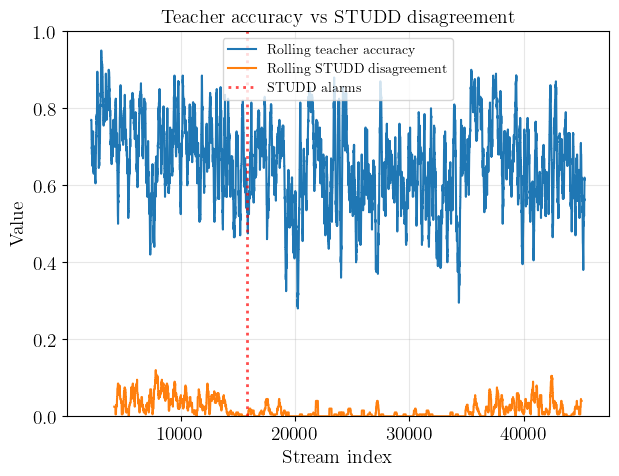

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_accuracy_df["t"],
    rolling_accuracy_df["rolling_teacher_accuracy"],
    label="Rolling teacher accuracy",
)

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_disagreement"],
    label="Rolling STUDD disagreement",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        linestyle=":",
        linewidth=2,
        alpha=0.7,
        label="STUDD alarms" if i == 0 else None,
    )

plt.title(
    "Teacher accuracy vs STUDD disagreement"
)

plt.xlabel("Stream index")
plt.ylabel("Value")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## STUDD agreement signal

This plot shows the teacher-student agreement signal.

High agreement means that the student is successfully mimicking the teacher.

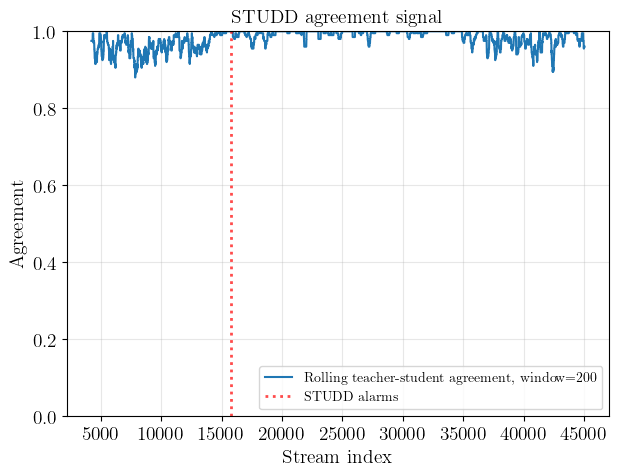

In [12]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_agreement"],
    label=f"Rolling teacher-student agreement, window={window}",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        linestyle=":",
        linewidth=2,
        alpha=0.7,
        label="STUDD alarms" if i == 0 else None,
    )

plt.title(
    "STUDD agreement signal"
)

plt.xlabel("Stream index")
plt.ylabel("Agreement")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## STUDD disagreement signal

This plot focuses only on the STUDD disagreement signal.

Since disagreement can be very small, we scale the y-axis based on the observed values rather than forcing it to `[0, 1]`.

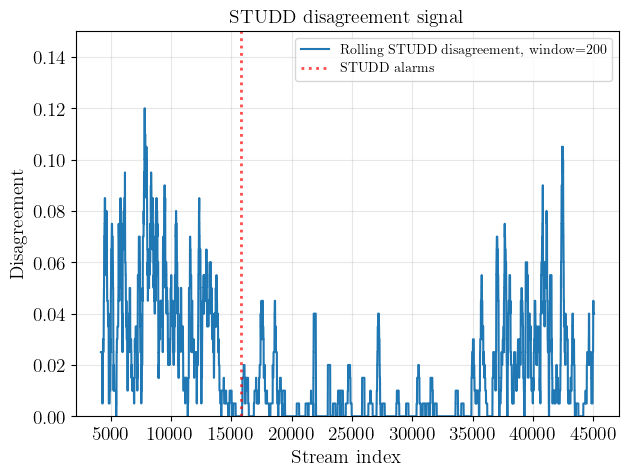

In [13]:
max_disagreement = rolling_studd_df[
    "rolling_disagreement"
].max()

upper_ylim = min(
    1.0,
    max_disagreement * 1.25
)

plt.figure(figsize=(7, 5))

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_disagreement"],
    label=f"Rolling STUDD disagreement, window={window}",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        linestyle=":",
        linewidth=2,
        alpha=0.7,
        label="STUDD alarms" if i == 0 else None,
    )

plt.title(
    "STUDD disagreement signal"
)

plt.xlabel("Stream index")
plt.ylabel("Disagreement")
plt.ylim(0, upper_ylim)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Focused view around all detected alarms

If alarms occur in a limited portion of the stream, a global plot may hide the local behavior.

Here, we automatically choose a focused interval that covers all detected alarms plus a margin of `LOCAL_WINDOW` instances.

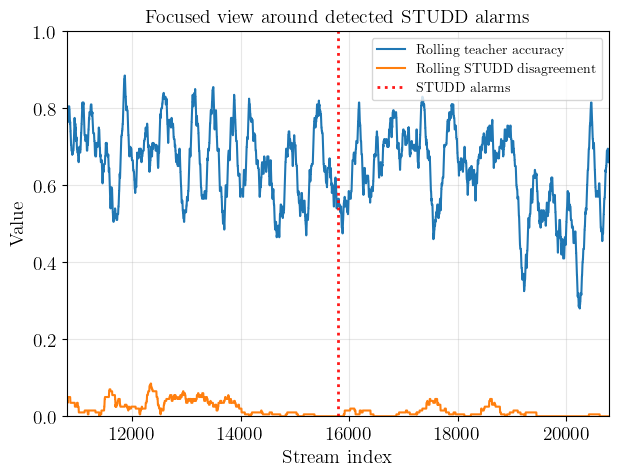

Focused interval: [10793, 20793]
Alarms in focused interval: [15793]


In [14]:
if studd_drift_points:

    focus_start = max(
        0,
        min(studd_drift_points) - LOCAL_WINDOW,
    )

    focus_end = max(studd_drift_points) + LOCAL_WINDOW

    accuracy_focus = rolling_accuracy_df[
        (rolling_accuracy_df["t"] >= focus_start)
        &
        (rolling_accuracy_df["t"] <= focus_end)
    ]

    studd_focus = rolling_studd_df[
        (rolling_studd_df["t"] >= focus_start)
        &
        (rolling_studd_df["t"] <= focus_end)
    ]

    alarms_focus = [
        dp for dp in studd_drift_points
        if focus_start <= dp <= focus_end
    ]

    plt.figure(figsize=(7, 5))

    plt.plot(
        accuracy_focus["t"],
        accuracy_focus["rolling_teacher_accuracy"],
        label="Rolling teacher accuracy",
    )

    plt.plot(
        studd_focus["t"],
        studd_focus["rolling_disagreement"],
        label="Rolling STUDD disagreement",
    )

    for i, dp in enumerate(alarms_focus):
        plt.axvline(
            dp,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.9,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(
        "Focused view around detected STUDD alarms"
    )

    plt.xlabel("Stream index")
    plt.ylabel("Value")
    plt.xlim(focus_start, focus_end)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(
        f"Focused interval: [{focus_start}, {focus_end}]"
    )

    print(
        f"Alarms in focused interval: {alarms_focus}"
    )

else:
    print("No STUDD alarms were detected.")

## Local view around each STUDD alarm

The previous plot shows all alarms together.

Here, we generate one local plot per alarm using a balanced interval of `LOCAL_WINDOW` instances before and after the alarm.

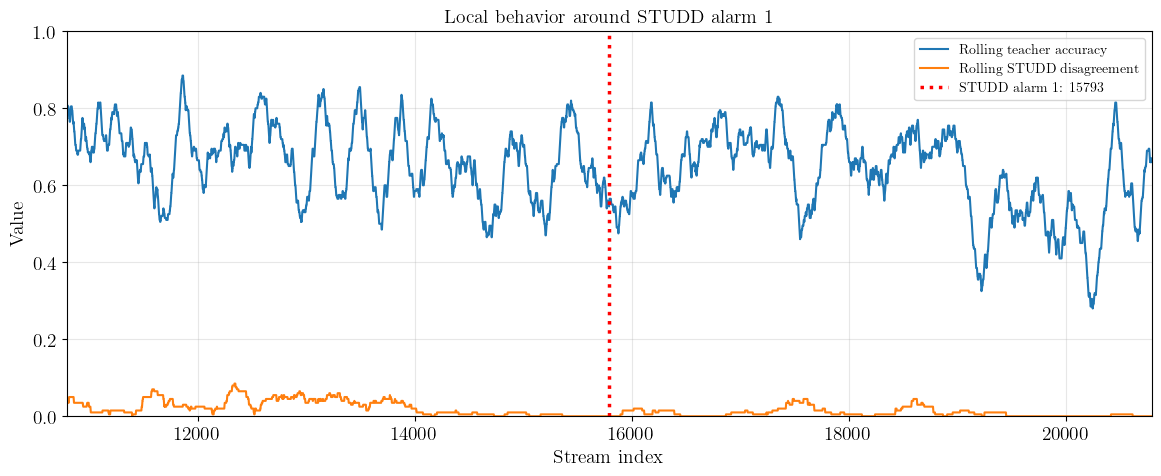

In [15]:
for alarm_id, alarm_t in enumerate(
    studd_drift_points,
    start=1,
):

    local_start = max(
        0,
        alarm_t - LOCAL_WINDOW,
    )

    local_end = alarm_t + LOCAL_WINDOW

    local_accuracy = rolling_accuracy_df[
        (rolling_accuracy_df["t"] >= local_start)
        &
        (rolling_accuracy_df["t"] <= local_end)
    ]

    local_studd = rolling_studd_df[
        (rolling_studd_df["t"] >= local_start)
        &
        (rolling_studd_df["t"] <= local_end)
    ]

    plt.figure(figsize=(14, 5))

    plt.plot(
        local_accuracy["t"],
        local_accuracy["rolling_teacher_accuracy"],
        label="Rolling teacher accuracy",
    )

    plt.plot(
        local_studd["t"],
        local_studd["rolling_disagreement"],
        label="Rolling STUDD disagreement",
    )

    plt.axvline(
        alarm_t,
        color="red",
        linestyle=":",
        linewidth=2.5,
        label=f"STUDD alarm {alarm_id}: {alarm_t}",
    )

    plt.title(
        f"Local behavior around STUDD alarm {alarm_id}"
    )

    plt.xlabel("Stream index")
    plt.ylabel("Value")
    plt.xlim(local_start, local_end)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Supervised signal baseline (SS)

We also monitor the teacher prediction error using Page-Hinkley.

Because this signal uses the true labels, it provides a supervised reference for evaluating the alarms produced by STUDD.

In [16]:
ss_detector = PageHinkley(
    delta=PH_DELTA,
)

ss_drift_points = []

teacher_error = (
    1.0 - results["teacher_correct"].to_numpy(dtype=float)
)

for t, err in zip(
    results["t"].to_numpy(),
    teacher_error,
):

    ss_detector.add_element(err)

    if ss_detector.detected_change():
        ss_drift_points.append(int(t))

print(f"Total STUDD detections: {len(studd_drift_points)}")
print(f"STUDD detections      : {studd_drift_points}")

print(f"Total SS detections   : {len(ss_drift_points)}")
print(f"SS detections         : {ss_drift_points}")

Total STUDD detections: 1
STUDD detections      : [15793]
Total SS detections   : 9
SS detections         : [7184, 19506, 20249, 22845, 27009, 32715, 34297, 39870, 40820]


## STUDD vs SS alarm comparison

Electricity does not provide ground-truth drift locations.

Following the STUDD paper, the first SS alarm is treated as a sign of a potential concept change and is used as a reference point for analysing the behaviour of the teacher-student disagreement signal.

We then examine whether STUDD raises alarms in similar regions of the stream without using class labels.


In [17]:
comparison_df = pd.DataFrame({
    "detector": (
        ["STUDD"] * len(studd_drift_points)
        +
        ["SS"] * len(ss_drift_points)
    ),
    "alarm_t": (
        [int(x) for x in studd_drift_points]
        +
        [int(x) for x in ss_drift_points]
    ),
})

comparison_df = (
    comparison_df
    .sort_values("alarm_t")
    .reset_index(drop=True)
)

comparison_df

,detector,alarm_t
0,SS,7184
1,STUDD,15793
2,SS,19506
3,SS,20249
4,SS,22845
5,SS,27009
6,SS,32715
7,SS,34297
8,SS,39870
9,SS,40820


## Visual comparison of STUDD and SS alarms

The following plot compares:

- rolling teacher accuracy
- STUDD alarms
- SS alarms

We visually check whether the two detectors react in similar regions of the stream.

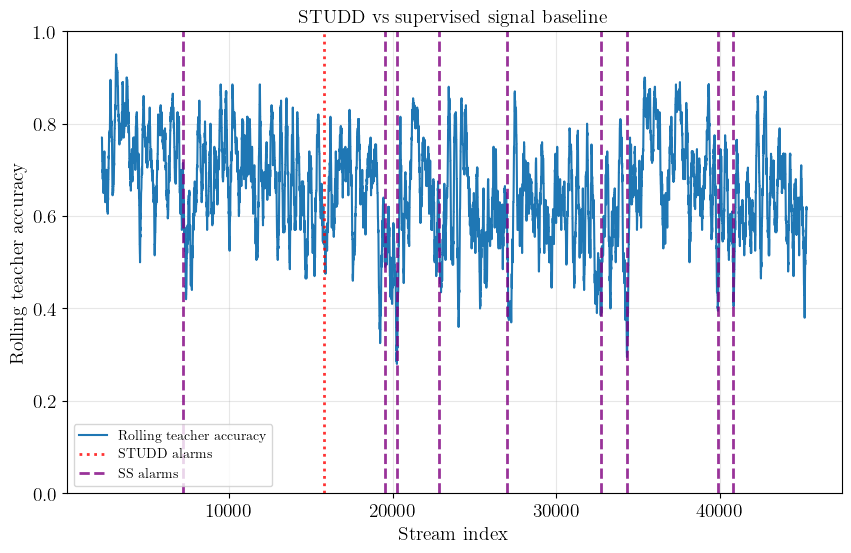

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    rolling_accuracy_df["t"],
    rolling_accuracy_df["rolling_teacher_accuracy"],
    label="Rolling teacher accuracy",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        linestyle=":",
        linewidth=2,
        alpha=0.8,
        label="STUDD alarms" if i == 0 else None,
    )

for i, dp in enumerate(ss_drift_points):
    plt.axvline(
        dp,
        color="purple",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label="SS alarms" if i == 0 else None,
    )

plt.title(
    "STUDD vs supervised signal baseline"
)
plt.xlabel("Stream index")
plt.ylabel("Rolling teacher accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Teacher-student disagreement and detector alarms

STUDD does not monitor teacher accuracy directly.  
It monitors the disagreement between the teacher and the student.

Therefore, we also plot the rolling teacher-student disagreement together with the alarms produced by STUDD and SS.

This helps us inspect whether the STUDD alarm appears in a region where the disagreement signal changes.

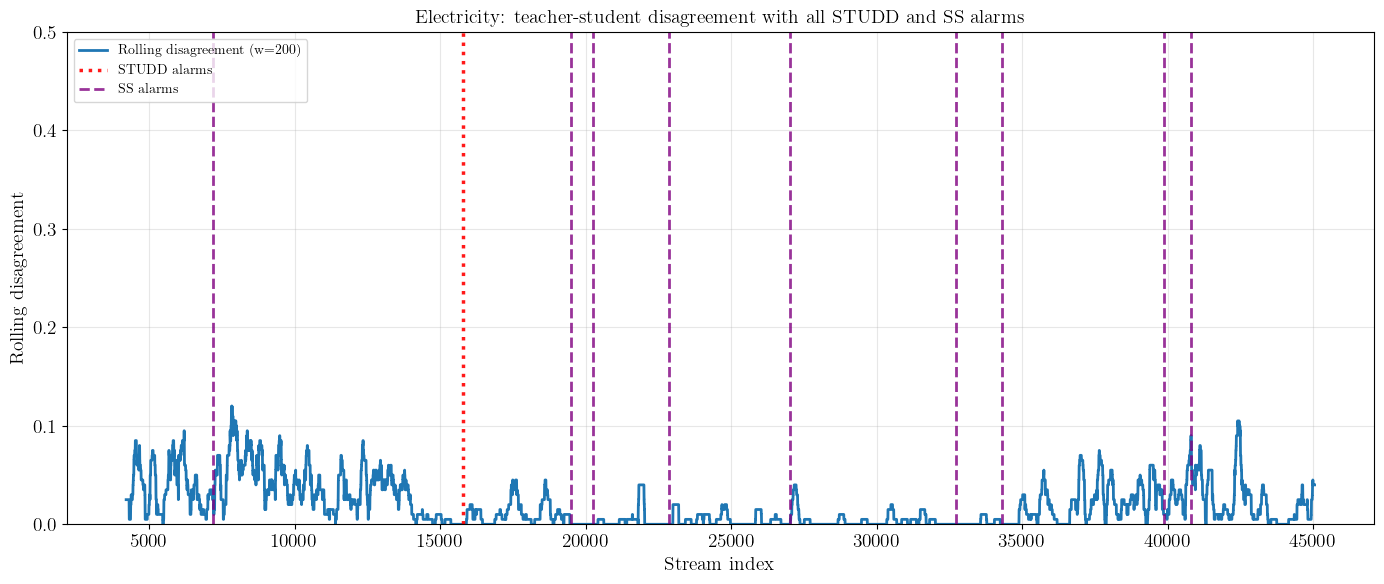

In [19]:
ROLLING_DISAGREEMENT_WINDOW = 200

rolling_disagreement_values, _ = rolling_mean(
    agreement_df["disagreement"].to_numpy(dtype=float),
    ROLLING_DISAGREEMENT_WINDOW,
)

rolling_disagreement_t = agreement_df["t"].to_numpy()[
    ROLLING_DISAGREEMENT_WINDOW - 1:
]

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_disagreement_t,
    rolling_disagreement_values,
    linewidth=2,
    label=f"Rolling disagreement (w={ROLLING_DISAGREEMENT_WINDOW})",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        int(dp),
        color="red",
        linestyle=":",
        linewidth=2.5,
        alpha=0.9,
        label="STUDD alarms" if i == 0 else None,
    )

for i, dp in enumerate(ss_drift_points):
    plt.axvline(
        int(dp),
        color="purple",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label="SS alarms" if i == 0 else None,
    )

plt.title("Electricity: teacher-student disagreement with all STUDD and SS alarms")
plt.xlabel("Stream index")
plt.ylabel("Rolling disagreement")
plt.ylim(0, 0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Local disagreement analysis around the STUDD alarm

We also examine the teacher-student disagreement around the alarm produced by STUDD.

This analysis shows whether the STUDD alarm is associated with a local change in the disagreement signal.

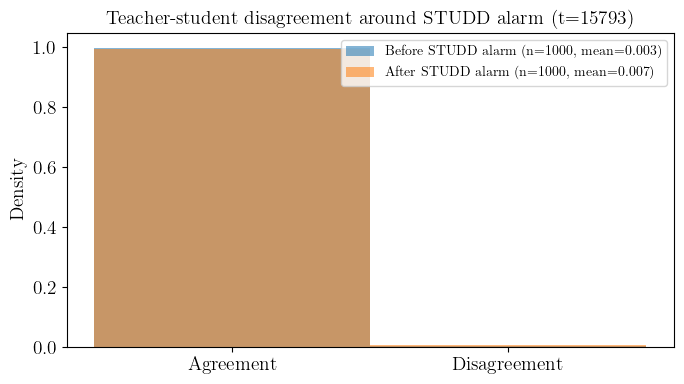

,studd_alarm,window,n_before,n_after,disagreement_before,disagreement_after,delta
0,15793,1000,1000,1000,0.003,0.007,0.004


In [23]:
LOCAL_WINDOW = 1000

reference_alarm = int(studd_drift_points[0])

before_alarm = agreement_df[
    (agreement_df["t"] >= reference_alarm - LOCAL_WINDOW)
    &
    (agreement_df["t"] < reference_alarm)
]

after_alarm = agreement_df[
    (agreement_df["t"] >= reference_alarm)
    &
    (agreement_df["t"] < reference_alarm + LOCAL_WINDOW)
]

before_disagreement = before_alarm["disagreement"].to_numpy(dtype=float)
after_disagreement = after_alarm["disagreement"].to_numpy(dtype=float)

mean_before = before_disagreement.mean()
mean_after = after_disagreement.mean()

fig, ax = plt.subplots(figsize=(7, 4))

bins = [-0.5, 0.5, 1.5]

ax.hist(
    before_disagreement,
    bins=bins,
    density=True,
    alpha=0.55,
    label=(
        f"Before STUDD alarm "
        f"(n={len(before_disagreement)}, mean={mean_before:.3f})"
    ),
)

ax.hist(
    after_disagreement,
    bins=bins,
    density=True,
    alpha=0.55,
    label=(
        f"After STUDD alarm "
        f"(n={len(after_disagreement)}, mean={mean_after:.3f})"
    ),
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Agreement",
    "Disagreement",
])

ax.set_ylabel("Density")
ax.set_title(
    f"Teacher-student disagreement around STUDD alarm (t={reference_alarm})"
)

ax.legend()

plt.tight_layout()
plt.show()

studd_alarm_disagreement_df = pd.DataFrame([{
    "studd_alarm": reference_alarm,
    "window": LOCAL_WINDOW,
    "n_before": len(before_disagreement),
    "n_after": len(after_disagreement),
    "disagreement_before": mean_before,
    "disagreement_after": mean_after,
    "delta": mean_after - mean_before,
}])

studd_alarm_disagreement_df

## Local disagreement analysis around all SS alarms

We now repeat the local before/after disagreement analysis for every SS alarm.

For each SS alarm, we compare the teacher-student disagreement during the 1000 observations immediately before and after the alarm.

This helps us examine whether the supervised reference alarms are also associated with local changes in the STUDD disagreement signal.

In [22]:
LOCAL_WINDOW = 1000

rows = []

for ss_alarm in ss_drift_points:

    ss_alarm = int(ss_alarm)

    before_alarm = agreement_df[
        (agreement_df["t"] >= ss_alarm - LOCAL_WINDOW)
        &
        (agreement_df["t"] < ss_alarm)
    ]

    after_alarm = agreement_df[
        (agreement_df["t"] >= ss_alarm)
        &
        (agreement_df["t"] < ss_alarm + LOCAL_WINDOW)
    ]

    before_disagreement = before_alarm["disagreement"].to_numpy(dtype=float)
    after_disagreement = after_alarm["disagreement"].to_numpy(dtype=float)

    mean_before = (
        before_disagreement.mean()
        if len(before_disagreement) > 0
        else np.nan
    )

    mean_after = (
        after_disagreement.mean()
        if len(after_disagreement) > 0
        else np.nan
    )

    rows.append({
        "ss_alarm": ss_alarm,
        "window": LOCAL_WINDOW,
        "n_before": len(before_disagreement),
        "n_after": len(after_disagreement),
        "disagreement_before": mean_before,
        "disagreement_after": mean_after,
        "delta": mean_after - mean_before,
    })

ss_alarm_disagreement_df = pd.DataFrame(rows)

ss_alarm_disagreement_df

,ss_alarm,window,n_before,n_after,disagreement_before,disagreement_after,delta
0,7184,1000,1000,1000,0.026,0.065,0.039
1,19506,1000,1000,1000,0.010,0.001,-0.009
2,20249,1000,1000,1000,0.002,0.002,0.000
3,22845,1000,1000,1000,0.000,0.007,0.007
4,27009,1000,1000,1000,0.002,0.009,0.007
5,32715,1000,1000,1000,0.001,0.002,0.001
6,34297,1000,1000,1000,0.003,0.008,0.005
7,39870,1000,1000,1000,0.031,0.035,0.004
8,40820,1000,1000,1000,0.035,0.031,-0.004


## Local comparison around STUDD alarms

For each STUDD alarm, we inspect the nearby SS detections and the local behaviour of the teacher accuracy signal.

The objective is to understand whether the disagreement-based detector reacts to the same changes identified by the supervised baseline.

In [21]:
MATCH_WINDOW = 2_000

match_rows = []

for studd_alarm in studd_drift_points:

    nearby_ss = [
        ss_alarm
        for ss_alarm in ss_drift_points
        if abs(ss_alarm - studd_alarm) <= MATCH_WINDOW
    ]

    match_rows.append({
        "studd_alarm": studd_alarm,
        "nearby_ss_alarms": nearby_ss,
        "num_nearby_ss_alarms": len(nearby_ss),
        "closest_ss_alarm": (
            min(
                nearby_ss,
                key=lambda x: abs(x - studd_alarm),
            )
            if nearby_ss
            else None
        ),
        "distance_to_closest_ss": (
            min(
                abs(x - studd_alarm)
                for x in nearby_ss
            )
            if nearby_ss
            else None
        ),
    })

studd_ss_match_df = pd.DataFrame(match_rows)
studd_ss_match_df

,studd_alarm,nearby_ss_alarms,num_nearby_ss_alarms,closest_ss_alarm,distance_to_closest_ss
0,15793,[],0,None,None
